# 05 - Evaluation: Experimental Schemas Comparison - Presentation Slides

## Import libraries and set the paths

In [1]:
from __future__ import annotations

import IPython.display as ipd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from myocardial_infarction_mortality.config import MODELS_DIR, FIGURES_DIR
from myocardial_infarction_mortality.evaluation.visual_evaluation import plot_model_distribution
from myocardial_infarction_mortality.evaluation.statistical_test_evaluation import compute_pairwise_corrected_resampled_ttest

2026-04-19 16:02:33.217 | INFO     | myocardial_infarction_mortality.config:<module>:16 - PROJ_ROOT path is: D:\2_UNIVERSITA\2_MAGISTRALE\1_ANNO\6_MACHINE_LEARNING\2-2023-2024\4-PROJECT\Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction


In [2]:
EXPERIMENTS_NAME = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
}

In [3]:
FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR = FIGURES_DIR / "EV_experimental_schemas_comparison_presentation"
FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
pd.set_option("display.max_columns", None)
plt.rcParams.update({"font.size": 16})
sns.set_style("whitegrid")
sns.set_palette("tab10")

## Data Loading and Basic Overview

In [5]:
all_frames = []

print(f"{'='*80}\nLOADING EXPERIMENTAL SCHEMAS\n{'='*80}")

for folder_name, schema_label in EXPERIMENTS_NAME.items():
    experiment_path = MODELS_DIR / folder_name

    # 1. Verify Folder Exists
    if not experiment_path.exists():
        print(f"[WARNING] Experiment folder not found: {folder_name}")
        continue

    # 2. Find Results Files (Recursively)
    # Looking for 'generalization_metrics_summary.csv' inside any model subfolder
    files = list(experiment_path.glob("**/generalization_metrics_summary.csv"))

    if not files:
        print(f"[SKIP] No results files found for schema: {schema_label}")
        continue

    print(f"Loading '{schema_label}' ({len(files)} files found)...")

    # 3. Load and Process Each File
    for f in files:
        try:
            df_temp = pd.read_csv(f)

            # A. Rename original 'model' to 'model_no_alias'
            df_temp.rename(columns={"model": "model_no_alias"}, inplace=True)

            # B. Create the NEW 'model' column (Concatenation)
            # Format: "ModelName (Alias)" -> e.g. "XGBoost (Cost-Sensitive)"
            df_temp["model"] = df_temp["model_no_alias"] + " (" + schema_label + ")"

            # C. Maintain experiment_name (Explicit check, though likely present)
            # If the CSV didn't have it, we could infer it from folder_name,
            # but usually it is already in the results file.
            if "experiment_name" not in df_temp.columns:
                df_temp["experiment_name"] = folder_name

            # D. Track schema label explicitly (optional, but good for filtering)
            df_temp["learning_schema"] = schema_label

            all_frames.append(df_temp)

        except Exception as e:
            print(f"  [ERROR] Could not read file {f.name}: {e}")

# --- 4. CONCATENATE MASTER DATAFRAME ---
generalization_df = pd.DataFrame()
if all_frames:
    generalization_df = pd.concat(all_frames, ignore_index=True)

    print("\n" + "="*80)
    print("SUCCESS: MASTER DATAFRAME CREATED")
    print("="*80)
    print(f"Total Evaluation Rows Loaded: {len(generalization_df)}")
    print(f"Total Unique Models (Tagged): {generalization_df['model'].nunique()}")

    # Validation: Preview the specific columns we modified
    print("\nPreview of Key Columns:")
    print(generalization_df[["experiment_name", "model_no_alias", "model"]].head())

else:
    print("\n[ERROR] No data loaded. Please check your MODELS_DIR path and folder names.")

LOADING EXPERIMENTAL SCHEMAS
Loading 'Baseline' (12 files found)...
Loading 'Balanced + STD' (12 files found)...
Loading 'Cost-sensitive + STD' (12 files found)...
Loading 'SMOTE + STD' (12 files found)...
Loading 'Balanced + MEC' (12 files found)...
Loading 'Cost-sensitive + MEC' (12 files found)...
Loading 'SMOTE + MEC' (12 files found)...

SUCCESS: MASTER DATAFRAME CREATED
Total Evaluation Rows Loaded: 8400
Total Unique Models (Tagged): 84

Preview of Key Columns:
      experiment_name          model_no_alias  \
0  baseline__standard  DecisionTreeClassifier   
1  baseline__standard  DecisionTreeClassifier   
2  baseline__standard  DecisionTreeClassifier   
3  baseline__standard  DecisionTreeClassifier   
4  baseline__standard  DecisionTreeClassifier   

                               model  
0  DecisionTreeClassifier (Baseline)  
1  DecisionTreeClassifier (Baseline)  
2  DecisionTreeClassifier (Baseline)  
3  DecisionTreeClassifier (Baseline)  
4  DecisionTreeClassifier (Baseline)  

In [6]:
generalization_df

,experiment_name,iteration,fold,model_no_alias,split,tp,tn,fp,fn,accuracy,precision,recall,f1,specificity,fpr,balanced_accuracy,geometric_mean,mcc,kappa,roc_auc,average_precision,average_cost,score_time,fold_size,selected_features_names,model,learning_schema
0,baseline__standard,1,1,DecisionTreeClassifier,generalization,4,131,2,21,0.854430,0.666667,0.160000,0.258065,0.984962,0.015038,0.572481,0.396981,0.276792,0.209656,0.572481,0.239578,1.341772,0.046126,158,"['num_log1p_standard_scaler__L_BLOOD', 'num_st...",DecisionTreeClassifier (Baseline),Baseline
1,baseline__standard,1,2,DecisionTreeClassifier,generalization,7,131,1,19,0.873418,0.875000,0.269231,0.411765,0.992424,0.007576,0.630828,0.516905,0.442499,0.362389,0.674971,0.397733,1.208861,0.044497,158,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DecisionTreeClassifier (Baseline),Baseline
2,baseline__standard,1,3,DecisionTreeClassifier,generalization,4,129,3,21,0.847134,0.571429,0.160000,0.250000,0.977273,0.022727,0.568636,0.395428,0.243359,0.193838,0.633182,0.250008,1.356688,0.043970,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_st...",DecisionTreeClassifier (Baseline),Baseline
3,baseline__standard,1,4,DecisionTreeClassifier,generalization,3,129,3,22,0.840764,0.500000,0.120000,0.193548,0.977273,0.022727,0.548636,0.342451,0.185645,0.140574,0.696970,0.307331,1.420382,0.043974,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DecisionTreeClassifier (Baseline),Baseline
4,baseline__standard,1,5,DecisionTreeClassifier,generalization,5,132,0,20,0.872611,1.000000,0.200000,0.333333,1.000000,0.000000,0.600000,0.447214,0.416754,0.295964,0.649545,0.361593,1.273885,0.044501,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DecisionTreeClassifier (Baseline),Baseline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8395,smote_auto__mec_fp1_fn10,10,6,XGBClassifier,generalization,24,77,55,1,0.643312,0.303797,0.960000,0.461538,0.583333,0.416667,0.771667,0.748331,0.397615,0.289708,0.904848,0.658034,0.414013,0.025432,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8396,smote_auto__mec_fp1_fn10,10,7,XGBClassifier,generalization,25,11,121,0,0.229299,0.171233,1.000000,0.292398,0.083333,0.916667,0.541667,0.288675,0.119455,0.028137,0.675606,0.303010,0.770701,0.022729,157,"['num_standard_scaler__AGE', 'num_standard_sca...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8397,smote_auto__mec_fp1_fn10,10,8,XGBClassifier,generalization,24,32,100,1,0.356688,0.193548,0.960000,0.322148,0.242424,0.757576,0.601212,0.482418,0.181782,0.077706,0.733939,0.461629,0.700637,0.022903,157,"['num_standard_scaler__AGE', 'num_standard_sca...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8398,smote_auto__mec_fp1_fn10,10,9,XGBClassifier,generalization,24,82,50,1,0.675159,0.324324,0.960000,0.484848,0.621212,0.378788,0.790606,0.772246,0.426027,0.323904,0.898788,0.706325,0.382166,0.025208,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",XGBClassifier (SMOTE + MEC),SMOTE + MEC


In [7]:
models_to_analyze = ["LogisticRegression",
                     "RandomForestClassifier",
                     "XGBClassifier",
                     "VotingClassifier",
                     "StackingClassifier",
                     "KNORAE",
                     "DESKL",
                     "METADES",
                     ]
print(f"Selected models:\n\t{models_to_analyze}")

generalization_df = generalization_df[generalization_df["model_no_alias"].isin(models_to_analyze)]
generalization_df

Selected models:
	['LogisticRegression', 'RandomForestClassifier', 'XGBClassifier', 'VotingClassifier', 'StackingClassifier', 'KNORAE', 'DESKL', 'METADES']


,experiment_name,iteration,fold,model_no_alias,split,tp,tn,fp,fn,accuracy,precision,recall,f1,specificity,fpr,balanced_accuracy,geometric_mean,mcc,kappa,roc_auc,average_precision,average_cost,score_time,fold_size,selected_features_names,model,learning_schema
100,baseline__standard,1,1,DESKL,generalization,3,132,1,22,0.854430,0.750000,0.120000,0.206897,0.992481,0.007519,0.556241,0.345105,0.261328,0.170698,0.764812,0.414571,1.398734,0.250332,158,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DESKL (Baseline),Baseline
101,baseline__standard,1,2,DESKL,generalization,8,131,1,18,0.879747,0.888889,0.307692,0.457143,0.992424,0.007576,0.650058,0.552595,0.480119,0.406954,0.796329,0.600120,1.145570,0.166502,158,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DESKL (Baseline),Baseline
102,baseline__standard,1,3,DESKL,generalization,3,132,0,22,0.859873,1.000000,0.120000,0.214286,1.000000,0.000000,0.560000,0.346410,0.320713,0.186528,0.871212,0.580750,1.401274,0.148144,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DESKL (Baseline),Baseline
103,baseline__standard,1,4,DESKL,generalization,0,130,2,25,0.828025,0.000000,0.000000,0.000000,0.984848,0.015152,0.492424,0.000000,-0.049435,-0.024160,0.873030,0.518707,1.605096,0.224802,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DESKL (Baseline),Baseline
104,baseline__standard,1,5,DESKL,generalization,5,132,0,20,0.872611,1.000000,0.200000,0.333333,1.000000,0.000000,0.600000,0.447214,0.416754,0.295964,0.779697,0.586524,1.273885,0.099766,157,"['num_standard_scaler__AGE', 'num_standard_sca...",DESKL (Baseline),Baseline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8395,smote_auto__mec_fp1_fn10,10,6,XGBClassifier,generalization,24,77,55,1,0.643312,0.303797,0.960000,0.461538,0.583333,0.416667,0.771667,0.748331,0.397615,0.289708,0.904848,0.658034,0.414013,0.025432,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8396,smote_auto__mec_fp1_fn10,10,7,XGBClassifier,generalization,25,11,121,0,0.229299,0.171233,1.000000,0.292398,0.083333,0.916667,0.541667,0.288675,0.119455,0.028137,0.675606,0.303010,0.770701,0.022729,157,"['num_standard_scaler__AGE', 'num_standard_sca...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8397,smote_auto__mec_fp1_fn10,10,8,XGBClassifier,generalization,24,32,100,1,0.356688,0.193548,0.960000,0.322148,0.242424,0.757576,0.601212,0.482418,0.181782,0.077706,0.733939,0.461629,0.700637,0.022903,157,"['num_standard_scaler__AGE', 'num_standard_sca...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8398,smote_auto__mec_fp1_fn10,10,9,XGBClassifier,generalization,24,82,50,1,0.675159,0.324324,0.960000,0.484848,0.621212,0.378788,0.790606,0.772246,0.426027,0.323904,0.898788,0.706325,0.382166,0.025208,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",XGBClassifier (SMOTE + MEC),SMOTE + MEC


## Slide 1 - Baseline vs Standard Threshold Approach: Accuracy / F1-score vs Average Cost

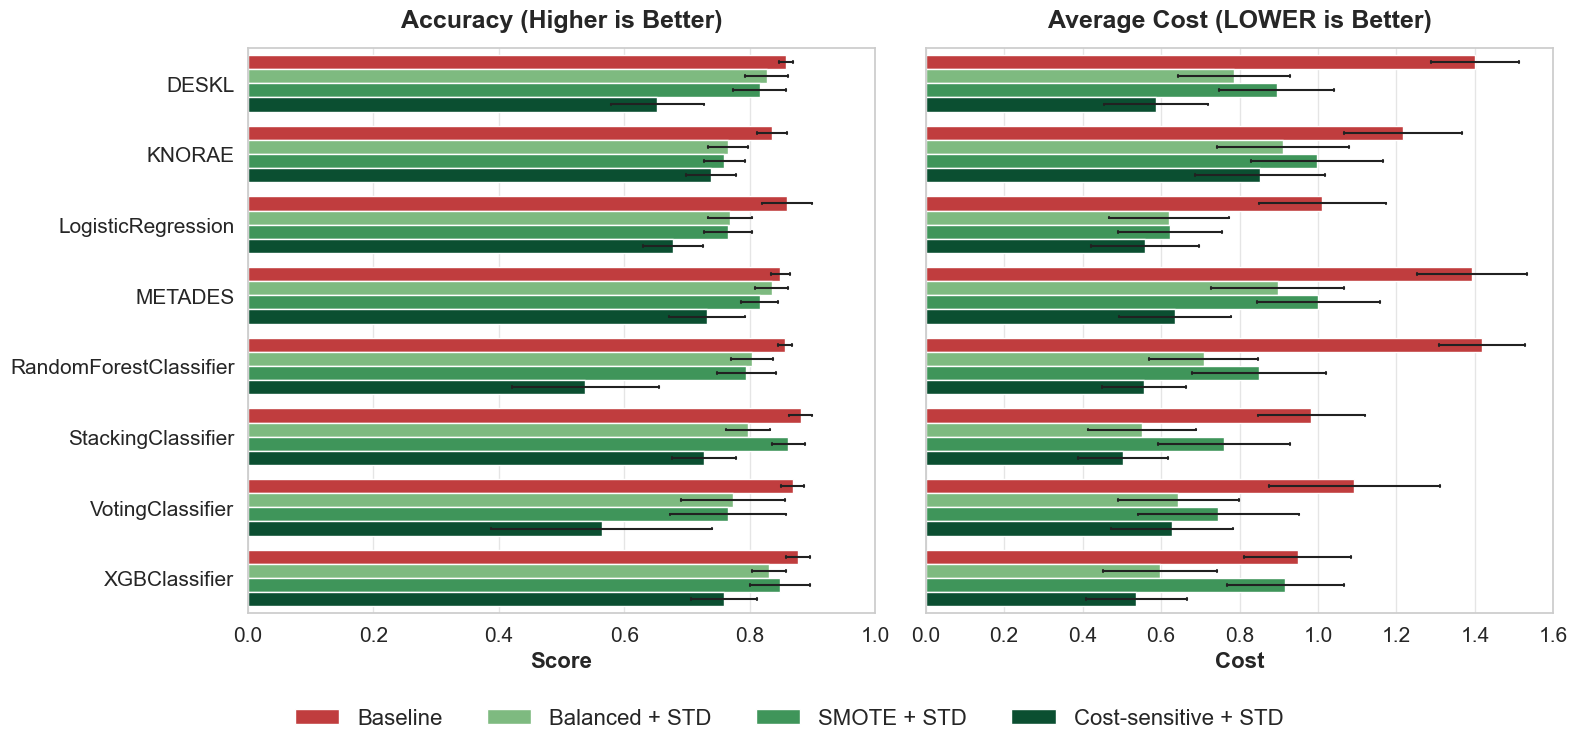

In [8]:
# Select the experiment to compare
experiments_mapping = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD"
}

# Filter and sort the dataframe
df_slide1 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping.keys())].copy()
df_slide1["experiment_name"] = pd.Categorical(
    df_slide1["experiment_name"].map(experiments_mapping),
    categories=list(experiments_mapping.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), sharey=True)

metrics = ["accuracy", "average_cost"]
titles = [
    "Accuracy (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 74c476: Light Green   -> balanced + STD
# 31a354: Medium Green  -> SMOTE + STD
# 005a32: Dark Green    -> Cost Sens + STD
colors = ["#d62728", "#74c476", "#31a354", "#005a32"]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide1,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors,
        errorbar="sd",
        capsize=0.1,
        err_kws={"linewidth": 1.5, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)
    axes[i].set_xlabel("Score" if metric == "accuracy" else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    if metric == "accuracy":
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

plt.tight_layout(rect=[0, 0.12, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=16,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide1_baseline_std_settings_accuracy_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

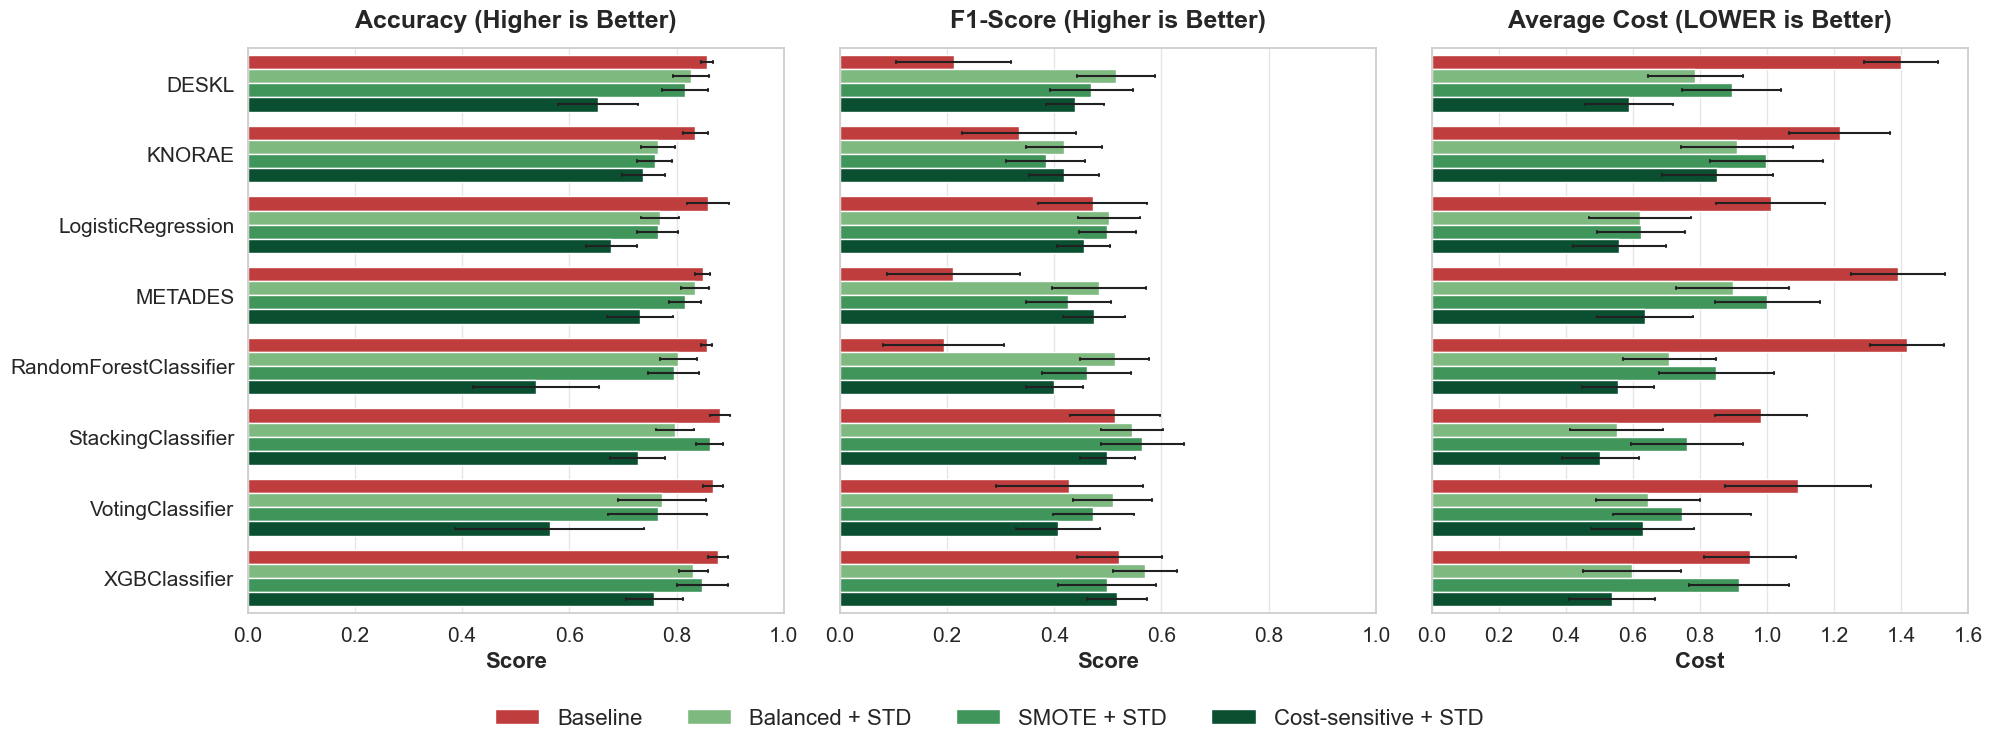

In [9]:
# Select the experiment to compare
experiments_mapping = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD"
}

# Filter and sort the dataframe
df_slide1 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping.keys())].copy()
df_slide1["experiment_name"] = pd.Categorical(
    df_slide1["experiment_name"].map(experiments_mapping),
    categories=list(experiments_mapping.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 8), sharey=True)

# Added "f1" to metrics and corresponding title
metrics = ["accuracy", "f1", "average_cost"]
titles = [
    "Accuracy (Higher is Better)",
    "F1-Score (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 74c476: Light Green   -> balanced + STD
# 31a354: Medium Green  -> SMOTE + STD
# 005a32: Dark Green    -> Cost Sens + STD
colors = ["#d62728", "#74c476", "#31a354", "#005a32"]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide1,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors,
        errorbar="sd",
        capsize=0.1,
        err_kws={"linewidth": 1.5, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)

    axes[i].set_xlabel("Score" if metric in ["accuracy", "f1"] else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    if metric in ["accuracy", "f1"]:
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)


    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

plt.tight_layout(rect=[0, 0.12, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=16,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide1_baseline_std_settings_accuracy_f1_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

## Slide 2 - Baseline vs MEC Threshold Approach: F1-score / Precision / Recall / Average Cost

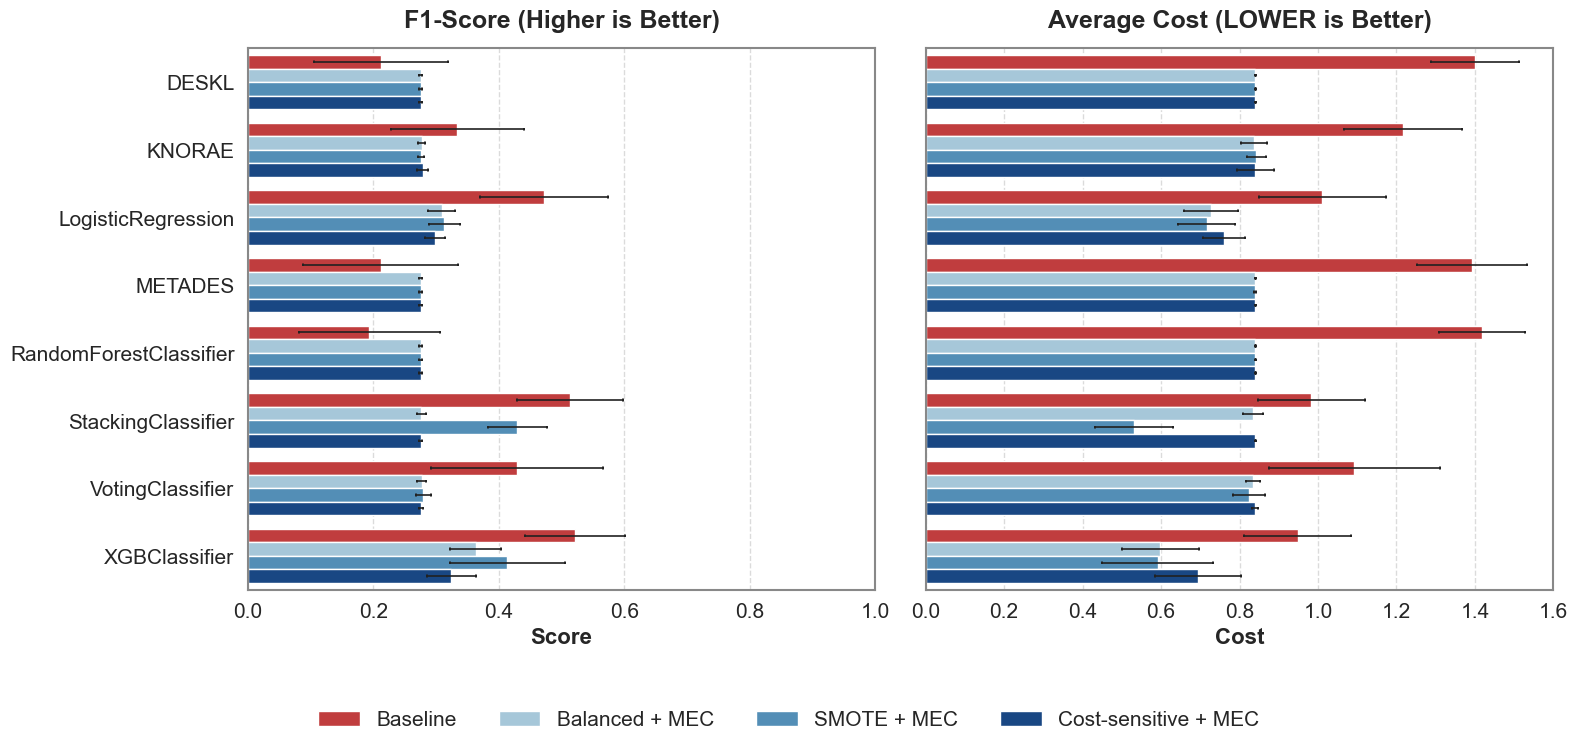

In [10]:
# Select the experiment to compare
experiments_mapping_all = {
    "baseline__standard": "Baseline",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide2 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping_all.keys())].copy()
df_slide2["experiment_name"] = pd.Categorical(
    df_slide2["experiment_name"].map(experiments_mapping_all),
    categories=list(experiments_mapping_all.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), sharey=True)

metrics = ["f1", "average_cost"]
titles = [
    "F1-Score (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 9ecae1: Light Blue    -> balanced + MEC
# 4292c6: Medium Blue   -> SMOTE + MEC
# 084594: Dark Blue     -> Cost Sens + MEC
colors_all = [
    "#d62728",
    "#9ecae1", "#4292c6", "#084594"
]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide2,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors_all,
        errorbar="sd",
        capsize=0.08,
        err_kws={"linewidth": 1.2, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)
    axes[i].set_xlabel("Score" if metric == "f1" else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    axes[i].yaxis.grid(False)
    axes[i].xaxis.grid(True, linestyle='--', alpha=0.7)

    if metric == "f1":
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()


plt.tight_layout(rect=[0, 0.15, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=15,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))


plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide2_baseline_mec_settings_f1_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

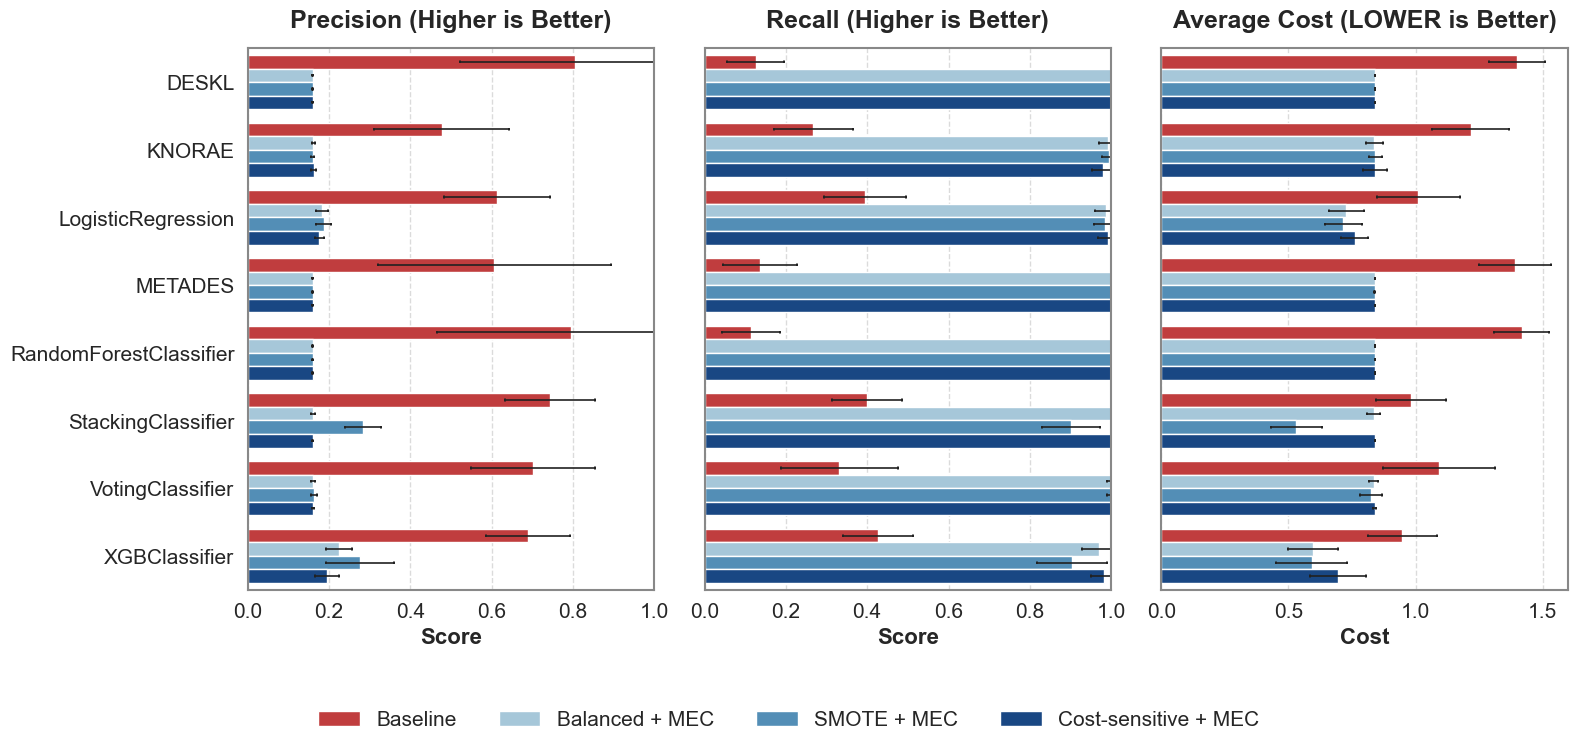

In [11]:
# Select the experiment to compare
experiments_mapping_all = {
    "baseline__standard": "Baseline",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide2 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping_all.keys())].copy()
df_slide2["experiment_name"] = pd.Categorical(
    df_slide2["experiment_name"].map(experiments_mapping_all),
    categories=list(experiments_mapping_all.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 8), sharey=True)

# Fix the metrics
metrics = ["precision", "recall", "average_cost"]
titles = [
    "Precision (Higher is Better)",
    "Recall (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 9ecae1: Light Blue    -> balanced + MEC
# 4292c6: Medium Blue   -> SMOTE + MEC
# 084594: Dark Blue     -> Cost Sens + MEC
colors_all = [
    "#d62728",
    "#9ecae1", "#4292c6", "#084594"
]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide2,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors_all,
        errorbar="sd",
        capsize=0.08,
        err_kws={"linewidth": 1.2, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)
    axes[i].set_xlabel("Score" if metric in ["precision", "recall"] else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    axes[i].yaxis.grid(False)
    axes[i].xaxis.grid(True, linestyle='--', alpha=0.7)

    if metric in ["precision", "recall"]:
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

plt.tight_layout(rect=[0, 0.15, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=15,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide2_baseline_mec_settings_precision_recall_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

## Slide 3 - All Experimental Approaches: F1-score / Precision / Recall / Average Cost

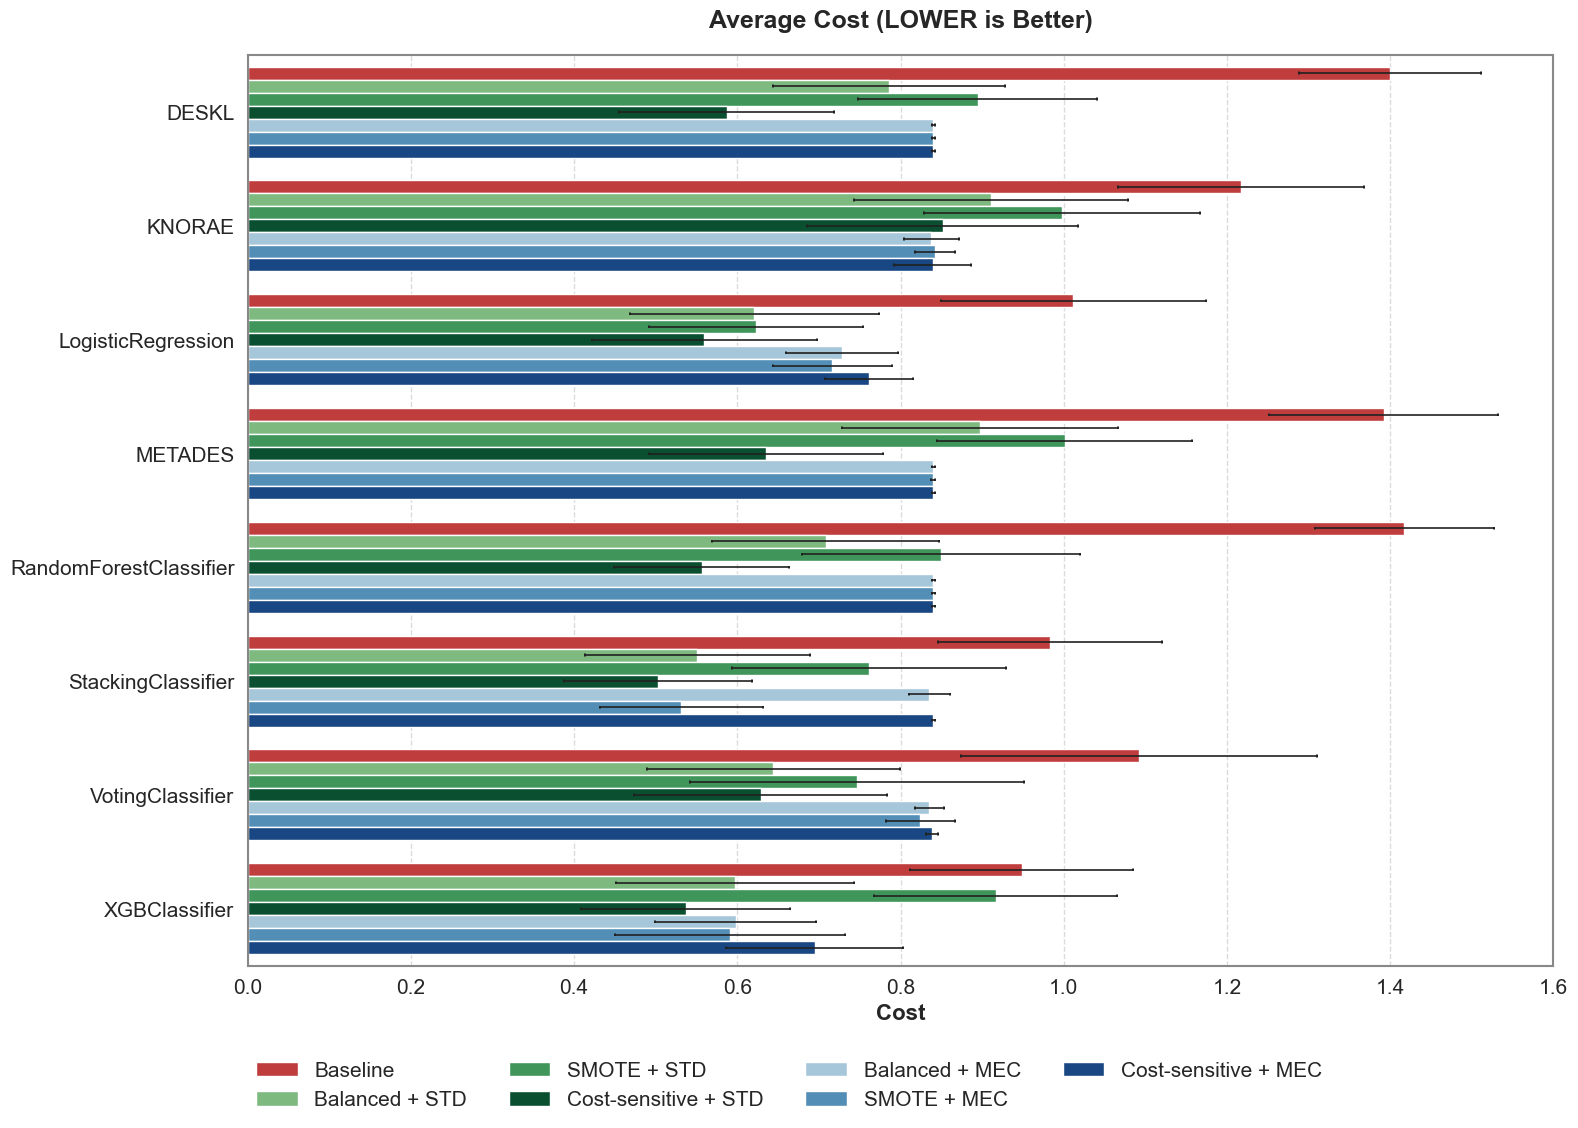

In [12]:
# Select the experiment to compare
experiments_mapping_all = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide3 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping_all.keys())].copy()
df_slide3["experiment_name"] = pd.Categorical(
    df_slide3["experiment_name"].map(experiments_mapping_all),
    categories=list(experiments_mapping_all.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, ax = plt.subplots(figsize=(16, 12))

# Fix the palette
# d62728: Red           -> baseline
# 74c476: Light Green   -> balanced + STD
# 31a354: Medium Green  -> SMOTE + STD
# 005a32: Dark Green    -> Cost Sens + STD
# 9ecae1: Light Blue    -> balanced + MEC
# 4292c6: Medium Blue   -> SMOTE + MEC
# 084594: Dark Blue     -> Cost Sens + MEC
colors_all = [
    "#d62728",
    "#74c476", "#31a354", "#005a32",
    "#9ecae1", "#4292c6", "#084594"
]

sns.barplot(
    data=df_slide3,
    x="average_cost",
    y="model_no_alias",
    hue="experiment_name",
    ax=ax,
    palette=colors_all,
    errorbar="sd",
    capsize=0.08,
    err_kws={"linewidth": 1.2, "color": "#212121"}
)

ax.set_title("Average Cost (LOWER is Better)", fontweight="bold", pad=20)
ax.set_xlabel("Cost", fontweight="bold")
ax.set_ylabel('')

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#888888')
    spine.set_linewidth(1.5)

ax.yaxis.grid(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_xlim(0, 1.6)

# 5. IL TOCCO DA MAESTRI: La Linea del Vincitore
# Dal tuo report sappiamo che Stacking (Cost-sensitive + STD) è il migliore a ~0.5024
#best_value = 0.5024
#ax.axvline(x=best_value, color='#005a32', linestyle='--', linewidth=3, zorder=0)

# Aggiungiamo un'annotazione per la linea
#ax.text(best_value + 0.01, len(df_slide3['model_no_alias'].unique()) - 0.5,
#        f'Best Overall ({best_value:.3f})',
#        color='#005a32', rotation=90, va='bottom', ha='left', fontsize=14, fontweight='bold')

if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.tight_layout(rect=[0, 0.12, 1, 1])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=15,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide3_all_settings_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

## Slide 4

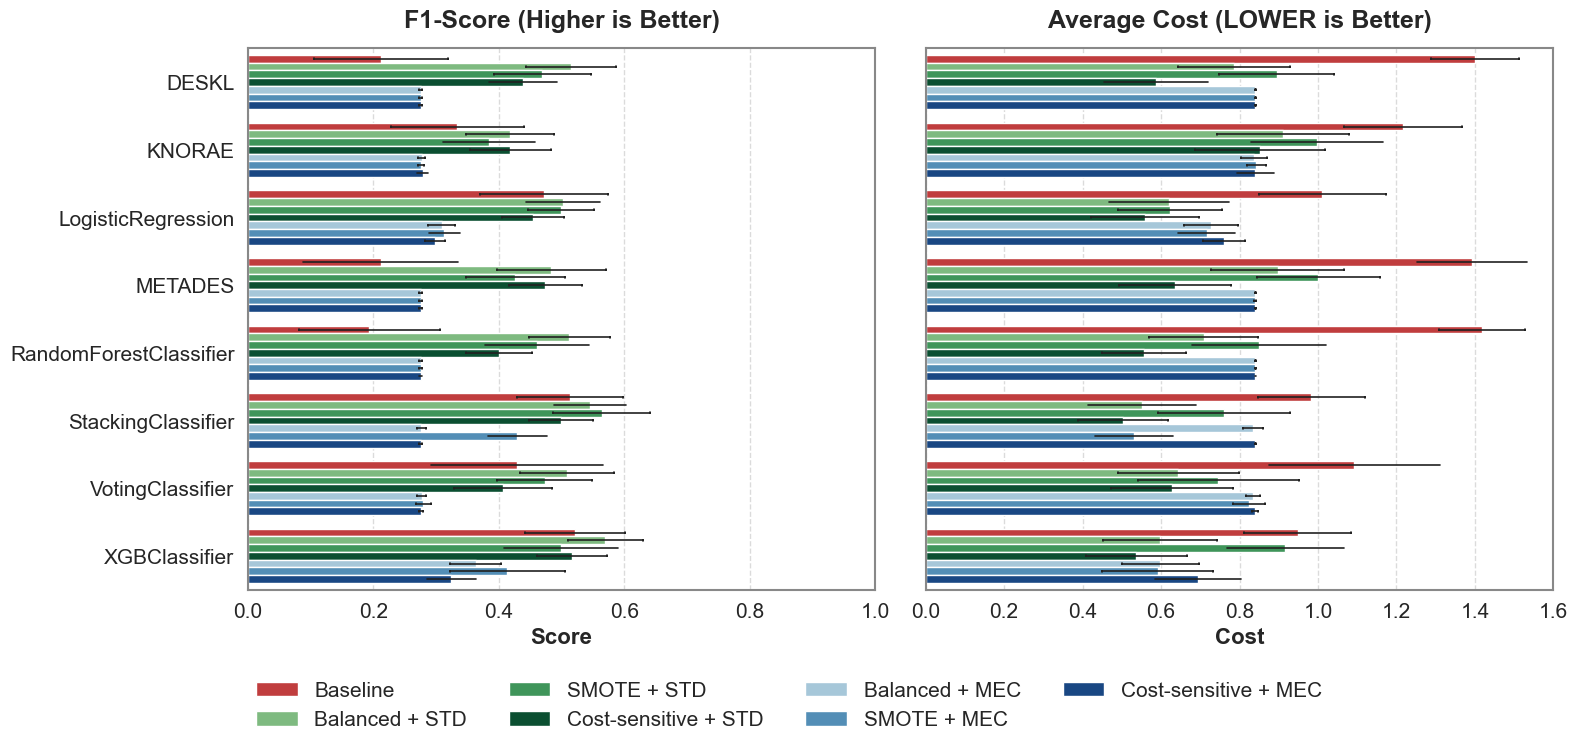

In [13]:
# Select the experiment to compare
experiments_mapping_all = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide3 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping_all.keys())].copy()
df_slide3["experiment_name"] = pd.Categorical(
    df_slide3["experiment_name"].map(experiments_mapping_all),
    categories=list(experiments_mapping_all.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), sharey=True)

metrics = ["f1", "average_cost"]
titles = [
    "F1-Score (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 74c476: Light Green   -> balanced + STD
# 31a354: Medium Green  -> SMOTE + STD
# 005a32: Dark Green    -> Cost Sens + STD
# 9ecae1: Light Blue    -> balanced + MEC
# 4292c6: Medium Blue   -> SMOTE + MEC
# 084594: Dark Blue     -> Cost Sens + MEC
colors_all = [
    "#d62728",
    "#74c476", "#31a354", "#005a32",
    "#9ecae1", "#4292c6", "#084594"
]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide3,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors_all,
        errorbar="sd",
        capsize=0.08,
        err_kws={"linewidth": 1.2, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)
    axes[i].set_xlabel("Score" if metric == "f1" else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    axes[i].yaxis.grid(False)
    axes[i].xaxis.grid(True, linestyle='--', alpha=0.7)

    if metric == "f1":
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()


plt.tight_layout(rect=[0, 0.15, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=15,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))


plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide3_all_settings_f1_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

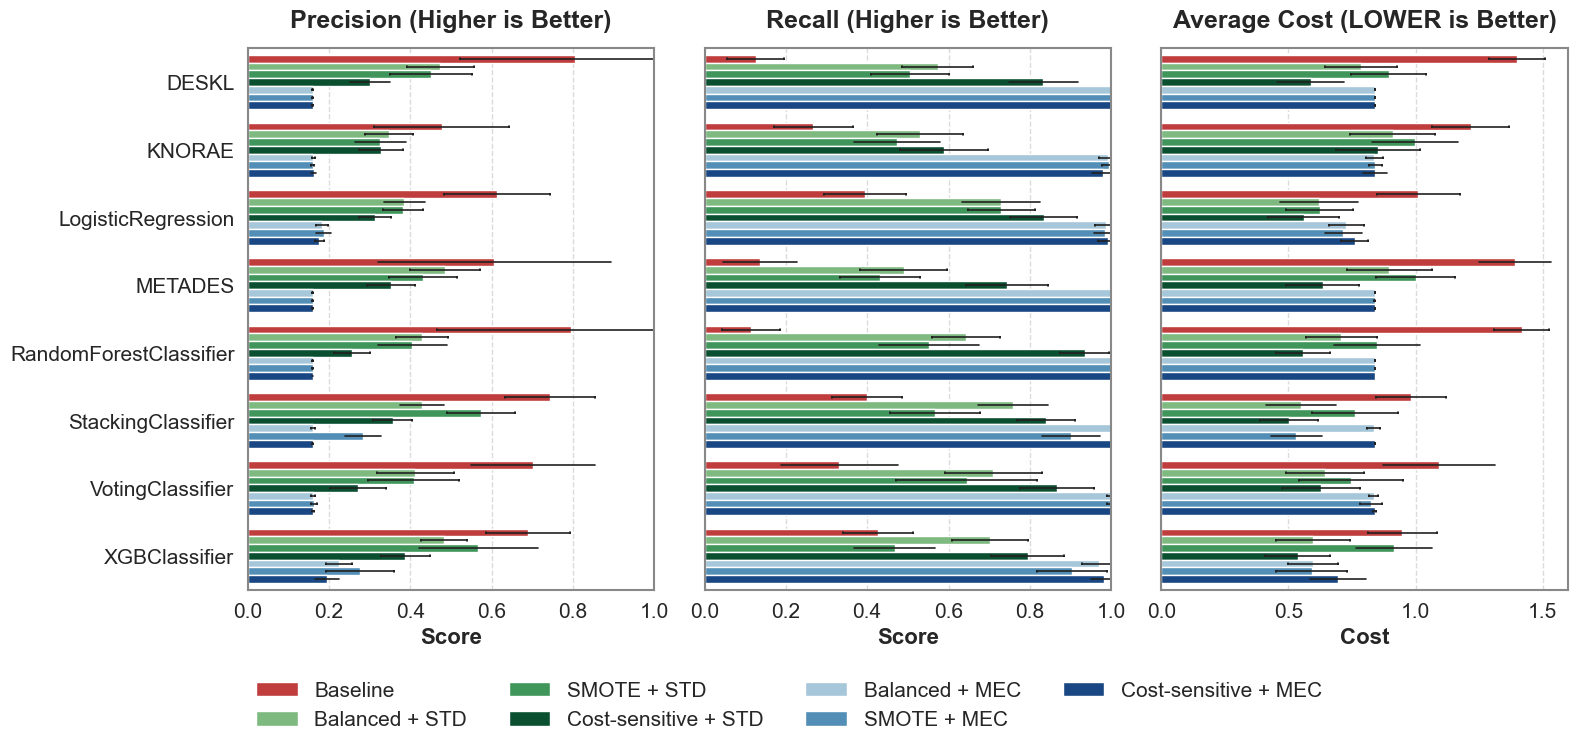

In [14]:
# Select the experiment to compare
experiments_mapping_all = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide3 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping_all.keys())].copy()
df_slide3["experiment_name"] = pd.Categorical(
    df_slide3["experiment_name"].map(experiments_mapping_all),
    categories=list(experiments_mapping_all.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 8), sharey=True)

# Fix the metrics
metrics = ["precision", "recall", "average_cost"]
titles = [
    "Precision (Higher is Better)",
    "Recall (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 74c476: Light Green   -> balanced + STD
# 31a354: Medium Green  -> SMOTE + STD
# 005a32: Dark Green    -> Cost Sens + STD
# 9ecae1: Light Blue    -> balanced + MEC
# 4292c6: Medium Blue   -> SMOTE + MEC
# 084594: Dark Blue     -> Cost Sens + MEC
colors_all = [
    "#d62728",
    "#74c476", "#31a354", "#005a32",
    "#9ecae1", "#4292c6", "#084594"
]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide3,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors_all,
        errorbar="sd",
        capsize=0.08,
        err_kws={"linewidth": 1.2, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)
    axes[i].set_xlabel("Score" if metric in ["precision", "recall"] else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    axes[i].yaxis.grid(False)
    axes[i].xaxis.grid(True, linestyle='--', alpha=0.7)

    if metric in ["precision", "recall"]:
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

plt.tight_layout(rect=[0, 0.15, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=15,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide3_all_settings_precision_recall_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Assumiamo che il dataframe sia 'generalization_df'

# 1. Selezioniamo esperimenti
experiments_mapping = {
    "baseline__standard": "Baseline",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD"
}

df_slide2 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping.keys())].copy()

# 2. Aggreghiamo i dati calcolando MEDIA e DEVIAZIONE STANDARD
# Creiamo due dataframe separati per facilitare l'estrazione
agg_mean = df_slide2.groupby(['model_no_alias', 'experiment_name'])[['f1', 'average_cost']].mean().unstack()
agg_std = df_slide2.groupby(['model_no_alias', 'experiment_name'])[['f1', 'average_cost']].std().unstack()

# Ordiniamo i modelli dal migliore al peggiore in base all'Average Cost del Cost-sensitive (sulla Media)
sort_order = agg_mean[('average_cost', 'csl_fp1_fn10__standard')].sort_values(ascending=True).index
agg_mean = agg_mean.loc[sort_order]
agg_std = agg_std.loc[sort_order]

# 3. Impostazioni grafiche
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

# Creiamo la figura 1x2 (aumentiamo leggermente la larghezza per far respirare il testo più lungo)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), sharey=True)

metrics = ["f1", "average_cost"]
titles = [
    "F1-Score (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

color_base = "#d62728"  # Rosso per Baseline
color_csl = "#005a32"   # Verde scuro per Cost-sensitive

y_positions = range(len(agg_mean))
model_names = agg_mean.index

# 4. Disegniamo i Dumbbell Plots nei due pannelli
for i, metric in enumerate(metrics):
    ax = axes[i]

    for idx, model in enumerate(model_names):
        # Valori per la Media
        val_base = agg_mean.loc[model, (metric, 'baseline__standard')]
        val_csl = agg_mean.loc[model, (metric, 'csl_fp1_fn10__standard')]

        # Valori per la Deviazione Standard
        std_base = agg_std.loc[model, (metric, 'baseline__standard')]
        std_csl = agg_std.loc[model, (metric, 'csl_fp1_fn10__standard')]

        # Linea di connessione
        ax.plot([val_base, val_csl], [idx, idx], color='grey', linewidth=2.5, zorder=1)

        # Punto Baseline (Rosso)
        ax.scatter(val_base, idx, color=color_base, s=200, zorder=2)

        # Punto Cost-Sensitive (Verde)
        ax.scatter(val_csl, idx, color=color_csl, s=200, zorder=2)

        # Formattazione testo con Matplotlib MathText per avere il simbolo +/- perfetto
        text_base = f"${val_base:.2f} \\pm {std_base:.2f}$"
        text_csl = f"${val_csl:.2f} \\pm {std_csl:.2f}$"

        # STRATEGIA ANTI-SOVRAPPOSIZIONE:
        # Mettiamo il testo della Baseline SOPRA il punto (idx - 0.25)
        # Mettiamo il testo del Cost-sensitive SOTTO il punto (idx + 0.25)
        # Usiamo un font leggermente più piccolo (11) per far rientrare la std dev
        ax.text(val_base, idx - 0.25, text_base, ha='center', va='center', fontsize=11, color=color_base, fontweight='bold')
        ax.text(val_csl, idx + 0.25, text_csl, ha='center', va='center', fontsize=11, color=color_csl, fontweight='bold')

    # Formattazione assi e Titoli
    ax.set_title(titles[i], fontweight="bold", pad=20)
    ax.set_xlabel("Score" if metric == "f1" else "Cost", fontweight="bold")
    ax.set_yticks(y_positions)
    ax.set_yticklabels(model_names, fontweight='bold')

    # BOX INTORNO AL PANNELLO:
    # Mostriamo e coloriamo di grigio scuro tutte e 4 le pareti del box (spines)
    for spine in ax.spines.values():
        spine.set_visible(False)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    ax.yaxis.grid(False) # Via le griglie orizzontali
    ax.xaxis.grid(True, linestyle='--', alpha=0.7) # Teniamo le griglie verticali

    # Impostazioni Limiti Asse X
    if metric == "f1":
        ax.set_xlim(0, 1.0)
    elif metric == "average_cost":
        ax.set_xlim(0, 1.8) # Forza l'Average Cost a partire da 0

# Invertiamo l'asse Y sul primo asse in modo che il modello migliore sia in alto
axes[0].invert_yaxis()

# 5. Titolo Principale e Legenda custom
#plt.suptitle('The Impact of Cost-Sensitive Learning Across All Model Families',
#             fontweight='bold', fontsize=24, y=1.05)

plt.tight_layout(rect=[0, 0.12, 1, 1])

# Legenda
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color_base, markersize=15, label='Baseline'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color_csl, markersize=15, label='Cost-sensitive + STD')
]

fig.legend(handles=custom_lines, loc="lower center", ncol=2, fontsize=16, frameon=False, bbox_to_anchor=(0.5, 0.05))

# ATTENZIONE: Ho rimosso sns.despine() per preservare il box attorno ai pannelli!

# plt.savefig("slide2_dumbbell_boxes_std.png", dpi=300, bbox_inches="tight")
plt.show()

## Single-Model Schema Sensitivity Analysis

#### Objective
To analyze how specific algorithms react to different learning schemas. By fixing the model architecture (e.g., isolating only **XGBoost** variants), we can determine which strategy is most effective for that specific algorithm.

#### Methodology
For each base model type (e.g., XGBoost):
1.  **Filtering:** We create a subset of data containing only variants of that specific model.
2.  **Comparative Plotting:** We generate a **Ranking Barplot** to visualize which schema yields the highest performance for that algorithm.
3.  **Significance Testing:** We apply pairwise t-tests within the subset to see if the schema-driven improvements are statistically significant.

### Model Comparison (Distribution Analysis)

#### Objective
To compare the performance distribution of all models for a specific metric on a targeted data split (e.g., Generalization or Resubstitution).

#### Methodology
We generate a **distribution plot** and a **statistical report** for the selected metric and split:
* **Scope:** Parametrizable (Default: **Generalization**).
* **Visualization:**
    * **Boxplot:** Displays the median, Interquartile Range (IQR), and spread.
    * **Strip Plot:** Overlays raw data points (100 folds) to visualize density.
* **Statistics:** A summary table (Mean, Std, Min, Max) is displayed and saved to quantify the visual results.
* **Sorting:** Models are sorted **Alphabetically** to ensure consistent ordering across different plots.
* **Scale:** Fixed to $0.0 - 1.0$ (or customized based on metric range).

#### Interpretation Guide
* **Box Height:** Higher is better for standard metrics (e.g., F1, MCC). Lower is better for error metrics.
* **Box Size (IQR):** A short box implies high stability (low variance). A tall box implies the model behavior changes drastically depending on the data fold.
* **Split Comparison:** By generating this plot for both 'resubstitution' and 'generalization', one can visually confirm overfitting (if the Resubstitution box is high/tight while the Generalization box is low/wide).

In [ ]:
for model in models_to_analyze:

    # List to store individual metric reports
    metric_reports = []

    print(f"Processing architecture: {model}...")

    model_save_path = FIGURES_SINGLE_MODELS_EVALUATION_DIR / model
    model_save_path.mkdir(parents=True, exist_ok=True)

    for metric in metrics_to_analyze:
        # Filter Data: Select ONLY rows belonging to this architecture
        # This subset will contain: "XGBoost (Standard)", "XGBoost (SMOTE)", etc.
        subset_df = generalization_df[generalization_df["model_no_alias"] == model].copy()

        report = plot_model_distribution(df=subset_df,
                                         metric_name=metric,
                                         save_path=model_save_path,
                                         split_name="generalization",
                                         figsize=(14,12))

        if report is not None:
            metric_reports.append(report)

    # --- Final Aggregation ---
    if metric_reports:
        # Concatenate all reports along columns (axis=1)
        # Since all reports share the same Index (Model Name), they will align automatically
        final_summary_df: pd.DataFrame = pd.concat(metric_reports, axis=1)

        print(f"\n{'='*80}\nFINAL DISTRIBUTION SUMMARY\n{'='*80}")
        ipd.display(final_summary_df)

        final_csv_path = model_save_path / "distribution_boxplot_summary.csv"
        final_summary_df.to_csv(final_csv_path)
    else:
        print("No reports were generated.")

### Model Comparison & Statistical Significance Testing

#### Objective
To definitively determine which models perform better than others by moving beyond simple average scores. We aim to identify **statistically significant differences** between model pairs, ensuring that observed performance gains are real and not merely artifacts of random data splitting.

#### Methodology: Corrected Resampled t-test
Standard statistical tests (like the independent t-test) assume that data samples are independent. However, in Cross-Validation, training sets overlap significantly (e.g., 90% overlap in 10-fold CV), violating this assumption and leading to underestimated variance and high False Positive rates (Type I errors).

To address this, we employ the **Corrected Resampled t-test** proposed by Nadeau and Bengio (2003). This test adjusts the variance to account for the correlation between training sets and the ratio of testing to training samples.

The corrected t-statistic is calculated as:

$$t = \frac{\mu_{diff}}{\sqrt{\sigma_{diff}^2 \cdot (\frac{1}{n} + \frac{n_{test}}{n_{train}})}}$$

Where:
* $\mu_{diff}$: Mean difference in scores between Model A and Model B.
* $\sigma_{diff}^2$: Variance of the differences.
* $n$: Number of evaluations (Iterations $\times$ Folds).
* $\frac{n_{test}}{n_{train}}$: Correction factor for the overlap between training sets.

#### Visualization: Pairwise Significance Heatmap
We visualize the results using a **Significance Heatmap** for each metric. This matrix displays the outcome of the hypothesis test for every pair of models based on the p-value.

* **Rows & Columns:** Each cell represents the comparison between the model on the row and the model on the column.
* **Color Coding:**
    * **Blue Cells ($p < 0.05$):** Indicate a **statistically significant difference**. Darker blues represent higher confidence (lower p-values, e.g., $p < 0.001$).
        * *Note:* This color confirms the models are *different*, but you must check the mean scores (or the CSV `Mean_Diff`) to see which one is *better*.
    * **Orange/Red Cells (NS):** Indicate **No Significant Difference**. The models perform statistically similarly, meaning any difference in their average scores is likely due to chance.

#### Interpretation Guide
1.  **Identify "Cliques":** Look for blocks of **Orange (NS)** cells. These represent groups of models that are statistically indistinguishable from each other.
2.  **Verify Improvements:** If a high-scoring model has a **Blue** cell when compared to a baseline model, the improvement is real and statistically significant.
3.  **Symmetry:** The chart is symmetric. A Blue cell at (Row A, Col B) means A and B are significantly different. Use the `df_comparisons` table to confirm if A > B or B > A.

In [ ]:
for model in models_to_analyze:

    # List to store individual metric reports
    pairwise_frames = []

    print(f"Processing architecture: {model}...")

    model_save_path = FIGURES_SINGLE_MODELS_EVALUATION_DIR / model
    model_save_path.mkdir(parents=True, exist_ok=True)

    for metric in metrics_to_analyze:

        # Filter Data: Select ONLY rows belonging to this architecture
        # This subset will contain: "XGBoost (Standard)", "XGBoost (SMOTE)", etc.
        subset_df = generalization_df[generalization_df["model_no_alias"] == model].copy()

        report = compute_pairwise_corrected_resampled_ttest(
            df=subset_df,
            metric_name=metric, # Pass single string here
            n_train=0.9,
            n_test=0.1,
            save_path=model_save_path,
            heatmap_figsize=(14,12),
            ranking_figsize=(14,12),
            ranking_value_label_fontsize=12,
        )

        if report is not None:
            pairwise_frames.append(report)

    # --- Final Aggregation ---
    if pairwise_frames:
        # Concatenate all reports along columns (axis=1)
        # Since all reports share the same Index (Model Name), they will align automatically
        final_summary_df: pd.DataFrame = pd.concat(pairwise_frames, axis=1)

        print(f"\n{'='*80}\nFINAL CORRECTED RESAMPLED t-TEST SUMMARY\n{'='*80}")
        ipd.display(final_summary_df)

        final_csv_path = model_save_path / "corrected_resampled_ttest_summary.csv"
        final_summary_df.to_csv(final_csv_path, index=False)
    else:
        print("No pairwise comparisons were generated.")

## Models Family Comparison: Static Ensemble Models
#### Objective
To identify the best-performing configuration across the entire experimental landscape. In this section, we compare all static ensemble models from all schemas with respect the simple baseline models .

#### Methodology
* **Ranking Analysis:** We rank all configurations by mean performance to identify the top-performing model/schema combination.
* **Statistical Significance:** We verify if the global winner is statistically distinct from the runners-up using pairwise t-tests and clique analysis.


In [ ]:
static_ens_models_to_analyze = ["LogisticRegression",
                                "RandomForestClassifier",
                                "XGBClassifier",
                                "VotingClassifier",
                                "StackingClassifier",
                                ]
print(f"Selected static ensemble models:\n\t{static_ens_models_to_analyze}")

generalization_static_ens_df = generalization_df[generalization_df["model_no_alias"].isin(static_ens_models_to_analyze)]
generalization_static_ens_df

### Model Comparison (Distribution Analysis)

#### Objective
To compare the performance distribution of all models for a specific metric on a targeted data split (e.g., Generalization or Resubstitution).

#### Methodology
We generate a **distribution plot** and a **statistical report** for the selected metric and split:
* **Scope:** Parametrizable (Default: **Generalization**).
* **Visualization:**
    * **Boxplot:** Displays the median, Interquartile Range (IQR), and spread.
    * **Strip Plot:** Overlays raw data points (100 folds) to visualize density.
* **Statistics:** A summary table (Mean, Std, Min, Max) is displayed and saved to quantify the visual results.
* **Sorting:** Models are sorted **Alphabetically** to ensure consistent ordering across different plots.
* **Scale:** Fixed to $0.0 - 1.0$ (or customized based on metric range).

#### Interpretation Guide
* **Box Height:** Higher is better for standard metrics (e.g., F1, MCC). Lower is better for error metrics.
* **Box Size (IQR):** A short box implies high stability (low variance). A tall box implies the model behavior changes drastically depending on the data fold.
* **Split Comparison:** By generating this plot for both 'resubstitution' and 'generalization', one can visually confirm overfitting (if the Resubstitution box is high/tight while the Generalization box is low/wide).

In [ ]:
# List to store individual metric reports
metric_reports = []

for metric in metrics_to_analyze:
    report = plot_model_distribution(df=generalization_static_ens_df,
                                     metric_name=metric,
                                     save_path=FIGURES_STATIC_ENS_MODELS_EVALUATION_DIR,
                                     split_name="generalization",
                                     figsize=(24,18))

    if report is not None:
        metric_reports.append(report)

# --- Final Aggregation ---
if metric_reports:
    # Concatenate all reports along columns (axis=1)
    # Since all reports share the same Index (Model Name), they will align automatically
    final_summary_df: pd.DataFrame = pd.concat(metric_reports, axis=1)

    print(f"\n{'='*80}\nFINAL DISTRIBUTION SUMMARY\n{'='*80}")
    ipd.display(final_summary_df)

    final_csv_path = FIGURES_STATIC_ENS_MODELS_EVALUATION_DIR / "distribution_boxplot_summary.csv"
    final_summary_df.to_csv(final_csv_path)
else:
    print("No reports were generated.")

### Model Comparison & Statistical Significance Testing

#### Objective
To definitively determine which models perform better than others by moving beyond simple average scores. We aim to identify **statistically significant differences** between model pairs, ensuring that observed performance gains are real and not merely artifacts of random data splitting.

#### Methodology: Corrected Resampled t-test
Standard statistical tests (like the independent t-test) assume that data samples are independent. However, in Cross-Validation, training sets overlap significantly (e.g., 90% overlap in 10-fold CV), violating this assumption and leading to underestimated variance and high False Positive rates (Type I errors).

To address this, we employ the **Corrected Resampled t-test** proposed by Nadeau and Bengio (2003). This test adjusts the variance to account for the correlation between training sets and the ratio of testing to training samples.

The corrected t-statistic is calculated as:

$$t = \frac{\mu_{diff}}{\sqrt{\sigma_{diff}^2 \cdot (\frac{1}{n} + \frac{n_{test}}{n_{train}})}}$$

Where:
* $\mu_{diff}$: Mean difference in scores between Model A and Model B.
* $\sigma_{diff}^2$: Variance of the differences.
* $n$: Number of evaluations (Iterations $\times$ Folds).
* $\frac{n_{test}}{n_{train}}$: Correction factor for the overlap between training sets.

#### Visualization: Pairwise Significance Heatmap
We visualize the results using a **Significance Heatmap** for each metric. This matrix displays the outcome of the hypothesis test for every pair of models based on the p-value.

* **Rows & Columns:** Each cell represents the comparison between the model on the row and the model on the column.
* **Color Coding:**
    * **Blue Cells ($p < 0.05$):** Indicate a **statistically significant difference**. Darker blues represent higher confidence (lower p-values, e.g., $p < 0.001$).
        * *Note:* This color confirms the models are *different*, but you must check the mean scores (or the CSV `Mean_Diff`) to see which one is *better*.
    * **Orange/Red Cells (NS):** Indicate **No Significant Difference**. The models perform statistically similarly, meaning any difference in their average scores is likely due to chance.

#### Interpretation Guide
1.  **Identify "Cliques":** Look for blocks of **Orange (NS)** cells. These represent groups of models that are statistically indistinguishable from each other.
2.  **Verify Improvements:** If a high-scoring model has a **Blue** cell when compared to a baseline model, the improvement is real and statistically significant.
3.  **Symmetry:** The chart is symmetric. A Blue cell at (Row A, Col B) means A and B are significantly different. Use the `df_comparisons` table to confirm if A > B or B > A.

In [ ]:
pairwise_frames = []

for metric in metrics_to_analyze:
    report = compute_pairwise_corrected_resampled_ttest(
        df=generalization_static_ens_df,
        metric_name=metric, # Pass single string here
        n_train=0.9,
        n_test=0.1,
        save_path=FIGURES_STATIC_ENS_MODELS_EVALUATION_DIR,
        heatmap_figsize=(18,18),
        ranking_figsize=(24,18),
        ranking_value_label_fontsize=14,
    )

    if report is not None:
        pairwise_frames.append(report)

# --- Aggregate & Save Master CSV ---
if pairwise_frames:
    # Concatenate all metric-specific dataframes vertically (stacking rows)
    final_comparisons_df: pd.DataFrame = pd.concat(pairwise_frames, axis=0)

    print(f"\n{'='*80}\nFINAL CORRECTED RESAMPLED t-TEST SUMMARY\n{'='*80}")
    ipd.display(final_comparisons_df)

    # Define filename
    final_csv_path = FIGURES_STATIC_ENS_MODELS_EVALUATION_DIR / "corrected_resampled_ttest_summary.csv"
    final_comparisons_df.to_csv(final_csv_path, index=False)
else:
    print("No pairwise comparisons were generated.")

## Models Family Comparison: DES Ensemble Models
#### Objective
To identify the best-performing configuration across the entire experimental landscape. In this section, we compare all des ensemble models from all schemas with respect the simple baseline models .

#### Methodology
* **Ranking Analysis:** We rank all configurations by mean performance to identify the top-performing model/schema combination.
* **Statistical Significance:** We verify if the global winner is statistically distinct from the runners-up using pairwise t-tests and clique analysis.

In [ ]:
des_ens_models_to_analyze = ["LogisticRegression",
                             "KNORAE",
                             "DESKL",
                             "METADES",
                            ]
print(f"Selected DES ensemble models:\n\t{des_ens_models_to_analyze}")

generalization_des_ens_df = generalization_df[generalization_df["model_no_alias"].isin(des_ens_models_to_analyze)]
generalization_des_ens_df

### Model Comparison (Distribution Analysis)

#### Objective
To compare the performance distribution of all models for a specific metric on a targeted data split (e.g., Generalization or Resubstitution).

#### Methodology
We generate a **distribution plot** and a **statistical report** for the selected metric and split:
* **Scope:** Parametrizable (Default: **Generalization**).
* **Visualization:**
    * **Boxplot:** Displays the median, Interquartile Range (IQR), and spread.
    * **Strip Plot:** Overlays raw data points (100 folds) to visualize density.
* **Statistics:** A summary table (Mean, Std, Min, Max) is displayed and saved to quantify the visual results.
* **Sorting:** Models are sorted **Alphabetically** to ensure consistent ordering across different plots.
* **Scale:** Fixed to $0.0 - 1.0$ (or customized based on metric range).

#### Interpretation Guide
* **Box Height:** Higher is better for standard metrics (e.g., F1, MCC). Lower is better for error metrics.
* **Box Size (IQR):** A short box implies high stability (low variance). A tall box implies the model behavior changes drastically depending on the data fold.
* **Split Comparison:** By generating this plot for both 'resubstitution' and 'generalization', one can visually confirm overfitting (if the Resubstitution box is high/tight while the Generalization box is low/wide).

In [ ]:
# List to store individual metric reports
metric_reports = []

for metric in metrics_to_analyze:
    report = plot_model_distribution(df=generalization_des_ens_df,
                                     metric_name=metric,
                                     save_path=FIGURES_DES_ENS_MODELS_EVALUATION_DIR,
                                     split_name="generalization",
                                     figsize=(24,18))

    if report is not None:
        metric_reports.append(report)

# --- Final Aggregation ---
if metric_reports:
    # Concatenate all reports along columns (axis=1)
    # Since all reports share the same Index (Model Name), they will align automatically
    final_summary_df: pd.DataFrame = pd.concat(metric_reports, axis=1)

    print(f"\n{'='*80}\nFINAL DISTRIBUTION SUMMARY\n{'='*80}")
    ipd.display(final_summary_df)

    final_csv_path = FIGURES_DES_ENS_MODELS_EVALUATION_DIR / "distribution_boxplot_summary.csv"
    final_summary_df.to_csv(final_csv_path)
else:
    print("No reports were generated.")

### Model Comparison & Statistical Significance Testing

#### Objective
To definitively determine which models perform better than others by moving beyond simple average scores. We aim to identify **statistically significant differences** between model pairs, ensuring that observed performance gains are real and not merely artifacts of random data splitting.

#### Methodology: Corrected Resampled t-test
Standard statistical tests (like the independent t-test) assume that data samples are independent. However, in Cross-Validation, training sets overlap significantly (e.g., 90% overlap in 10-fold CV), violating this assumption and leading to underestimated variance and high False Positive rates (Type I errors).

To address this, we employ the **Corrected Resampled t-test** proposed by Nadeau and Bengio (2003). This test adjusts the variance to account for the correlation between training sets and the ratio of testing to training samples.

The corrected t-statistic is calculated as:

$$t = \frac{\mu_{diff}}{\sqrt{\sigma_{diff}^2 \cdot (\frac{1}{n} + \frac{n_{test}}{n_{train}})}}$$

Where:
* $\mu_{diff}$: Mean difference in scores between Model A and Model B.
* $\sigma_{diff}^2$: Variance of the differences.
* $n$: Number of evaluations (Iterations $\times$ Folds).
* $\frac{n_{test}}{n_{train}}$: Correction factor for the overlap between training sets.

#### Visualization: Pairwise Significance Heatmap
We visualize the results using a **Significance Heatmap** for each metric. This matrix displays the outcome of the hypothesis test for every pair of models based on the p-value.

* **Rows & Columns:** Each cell represents the comparison between the model on the row and the model on the column.
* **Color Coding:**
    * **Blue Cells ($p < 0.05$):** Indicate a **statistically significant difference**. Darker blues represent higher confidence (lower p-values, e.g., $p < 0.001$).
        * *Note:* This color confirms the models are *different*, but you must check the mean scores (or the CSV `Mean_Diff`) to see which one is *better*.
    * **Orange/Red Cells (NS):** Indicate **No Significant Difference**. The models perform statistically similarly, meaning any difference in their average scores is likely due to chance.

#### Interpretation Guide
1.  **Identify "Cliques":** Look for blocks of **Orange (NS)** cells. These represent groups of models that are statistically indistinguishable from each other.
2.  **Verify Improvements:** If a high-scoring model has a **Blue** cell when compared to a baseline model, the improvement is real and statistically significant.
3.  **Symmetry:** The chart is symmetric. A Blue cell at (Row A, Col B) means A and B are significantly different. Use the `df_comparisons` table to confirm if A > B or B > A.

In [ ]:
pairwise_frames = []

for metric in metrics_to_analyze:
    report = compute_pairwise_corrected_resampled_ttest(
        df=generalization_des_ens_df,
        metric_name=metric, # Pass single string here
        n_train=0.9,
        n_test=0.1,
        save_path=FIGURES_DES_ENS_MODELS_EVALUATION_DIR,
        heatmap_figsize=(18,18),
        ranking_figsize=(24,18),
        ranking_value_label_fontsize=14,
    )

    if report is not None:
        pairwise_frames.append(report)

# --- Aggregate & Save Master CSV ---
if pairwise_frames:
    # Concatenate all metric-specific dataframes vertically (stacking rows)
    final_comparisons_df: pd.DataFrame = pd.concat(pairwise_frames, axis=0)

    print(f"\n{'='*80}\nFINAL CORRECTED RESAMPLED t-TEST SUMMARY\n{'='*80}")
    ipd.display(final_comparisons_df)

    # Define filename
    final_csv_path = FIGURES_DES_ENS_MODELS_EVALUATION_DIR / "corrected_resampled_ttest_summary.csv"
    final_comparisons_df.to_csv(final_csv_path, index=False)
else:
    print("No pairwise comparisons were generated.")

## Global Cross-Schema Comparison

#### Objective
To identify the absolute best-performing configuration across the entire experimental landscape. In this section, we pool all models from all schemas into a single "Master Leaderboard" to find the global optimum.

#### Methodology
* **Ranking Analysis:** We rank all configurations by mean performance to identify the top-performing model/schema combination.
* **Statistical Significance:** We verify if the global winner is statistically distinct from the runners-up using pairwise t-tests and clique analysis.

### Model Comparison (Distribution Analysis)

#### Objective
To compare the performance distribution of all models for a specific metric on a targeted data split (e.g., Generalization or Resubstitution).

#### Methodology
We generate a **distribution plot** and a **statistical report** for the selected metric and split:
* **Scope:** Parametrizable (Default: **Generalization**).
* **Visualization:**
    * **Boxplot:** Displays the median, Interquartile Range (IQR), and spread.
    * **Strip Plot:** Overlays raw data points (100 folds) to visualize density.
* **Statistics:** A summary table (Mean, Std, Min, Max) is displayed and saved to quantify the visual results.
* **Sorting:** Models are sorted **Alphabetically** to ensure consistent ordering across different plots.
* **Scale:** Fixed to $0.0 - 1.0$ (or customized based on metric range).

#### Interpretation Guide
* **Box Height:** Higher is better for standard metrics (e.g., F1, MCC). Lower is better for error metrics.
* **Box Size (IQR):** A short box implies high stability (low variance). A tall box implies the model behavior changes drastically depending on the data fold.
* **Split Comparison:** By generating this plot for both 'resubstitution' and 'generalization', one can visually confirm overfitting (if the Resubstitution box is high/tight while the Generalization box is low/wide).

In [ ]:
# List to store individual metric reports
metric_reports = []

for metric in metrics_to_analyze:
    report = plot_model_distribution(df=generalization_df,
                                     metric_name=metric,
                                     save_path=FIGURES_MULTIPLE_MODELS_EVALUATION_DIR,
                                     split_name="generalization",
                                     figsize=(24,18))

    if report is not None:
        metric_reports.append(report)

# --- Final Aggregation ---
if metric_reports:
    # Concatenate all reports along columns (axis=1)
    # Since all reports share the same Index (Model Name), they will align automatically
    final_summary_df: pd.DataFrame = pd.concat(metric_reports, axis=1)

    print(f"\n{'='*80}\nFINAL DISTRIBUTION SUMMARY\n{'='*80}")
    ipd.display(final_summary_df)

    final_csv_path = FIGURES_MULTIPLE_MODELS_EVALUATION_DIR / "distribution_boxplot_summary.csv"
    final_summary_df.to_csv(final_csv_path)
else:
    print("No reports were generated.")

### Model Comparison & Statistical Significance Testing

#### Objective
To definitively determine which models perform better than others by moving beyond simple average scores. We aim to identify **statistically significant differences** between model pairs, ensuring that observed performance gains are real and not merely artifacts of random data splitting.

#### Methodology: Corrected Resampled t-test
Standard statistical tests (like the independent t-test) assume that data samples are independent. However, in Cross-Validation, training sets overlap significantly (e.g., 90% overlap in 10-fold CV), violating this assumption and leading to underestimated variance and high False Positive rates (Type I errors).

To address this, we employ the **Corrected Resampled t-test** proposed by Nadeau and Bengio (2003). This test adjusts the variance to account for the correlation between training sets and the ratio of testing to training samples.

The corrected t-statistic is calculated as:

$$t = \frac{\mu_{diff}}{\sqrt{\sigma_{diff}^2 \cdot (\frac{1}{n} + \frac{n_{test}}{n_{train}})}}$$

Where:
* $\mu_{diff}$: Mean difference in scores between Model A and Model B.
* $\sigma_{diff}^2$: Variance of the differences.
* $n$: Number of evaluations (Iterations $\times$ Folds).
* $\frac{n_{test}}{n_{train}}$: Correction factor for the overlap between training sets.

#### Visualization: Pairwise Significance Heatmap
We visualize the results using a **Significance Heatmap** for each metric. This matrix displays the outcome of the hypothesis test for every pair of models based on the p-value.

* **Rows & Columns:** Each cell represents the comparison between the model on the row and the model on the column.
* **Color Coding:**
    * **Blue Cells ($p < 0.05$):** Indicate a **statistically significant difference**. Darker blues represent higher confidence (lower p-values, e.g., $p < 0.001$).
        * *Note:* This color confirms the models are *different*, but you must check the mean scores (or the CSV `Mean_Diff`) to see which one is *better*.
    * **Orange/Red Cells (NS):** Indicate **No Significant Difference**. The models perform statistically similarly, meaning any difference in their average scores is likely due to chance.

#### Interpretation Guide
1.  **Identify "Cliques":** Look for blocks of **Orange (NS)** cells. These represent groups of models that are statistically indistinguishable from each other.
2.  **Verify Improvements:** If a high-scoring model has a **Blue** cell when compared to a baseline model, the improvement is real and statistically significant.
3.  **Symmetry:** The chart is symmetric. A Blue cell at (Row A, Col B) means A and B are significantly different. Use the `df_comparisons` table to confirm if A > B or B > A.

In [ ]:
pairwise_frames = []

for metric in metrics_to_analyze:
    report = compute_pairwise_corrected_resampled_ttest(
        df=generalization_df,
        metric_name=metric, # Pass single string here
        n_train=0.9,
        n_test=0.1,
        save_path=FIGURES_MULTIPLE_MODELS_EVALUATION_DIR,
        heatmap_figsize=(22,22),
        ranking_figsize=(24,18),
        ranking_value_label_fontsize=14,
    )

    if report is not None:
        pairwise_frames.append(report)

# --- Aggregate & Save Master CSV ---
if pairwise_frames:
    # Concatenate all metric-specific dataframes vertically (stacking rows)
    final_comparisons_df: pd.DataFrame = pd.concat(pairwise_frames, axis=0)

    print(f"\n{'='*80}\nFINAL CORRECTED RESAMPLED t-TEST SUMMARY\n{'='*80}")
    ipd.display(final_comparisons_df)

    # Define filename
    final_csv_path = FIGURES_MULTIPLE_MODELS_EVALUATION_DIR / "corrected_resampled_ttest_summary.csv"
    final_comparisons_df.to_csv(final_csv_path, index=False)
else:
    print("No pairwise comparisons were generated.")